In [1]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units

%matplotlib inline

In [6]:
def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level = 0.95, r2_min = 0.7):

    # Create a 1x1 grid of subplots with a more square-like figure size
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)

    # Loop through each method
    for c, method in enumerate(['IDF']):
        taus = []
        fit_function = fitting_for_method[method]
    
        for icond in iconds:
            try:
                with h5py.File(f'{method}_icond_{icond}/mem_data.hdf', 'r') as F:
                    sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                    md_time = np.array(F['time/data'][:]) * units.au2fs
            except FileNotFoundError:
                print(f"File not found: {method}_icond_{icond}/mem_data.hdf, skipping.")
                continue

            popt, pcov = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
            tau = popt
            residuals = sh_pop - fit_function(md_time, *popt)
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
            r_squared = 1.0 - (ss_res / ss_tot)

            print(f"icond: {icond}, r_squared: {r_squared}, tau: {tau}")  # Print r_squared for each icond

            # Only append tau and plot if r_squared is greater than 0.1        
            if r_squared > r2_min:
                ax.plot(md_time, sh_pop, color='blue', linewidth=2.0)  # Line color is black
                taus.append(tau)
                print(F"plotting this batch, the fitted tau is {tau}")
            else:
                ax.plot(md_time, sh_pop, color='grey', linewidth=2.0) 

        taus = np.array(taus)
        if len(taus) > 0:  # Proceed only if there are valid taus
            ave_tau = np.average(taus)
            s = np.std(taus)            
            N = taus.shape[0]
            #Z = 1.96 - naive value
            Z = stdtrit(N-1, conf_level) # better approach
            print(F"Z = {Z}")
            error_bar = Z * s / np.sqrt(N) 
        
            # Convert timescale to picoseconds (ps)
            ave_tau_ps = ave_tau / 1000
            error_bar_ps = error_bar / 1000
        
            print(f'The timescales for method {method}: \n {ave_tau_ps}+-{error_bar_ps} ps, averaged over {len(taus)} samples')

            ax.plot(md_time, fit_function(md_time, ave_tau - error_bar), ls='--', color="red", linewidth=2.0)
        
            # Increase the linewidth of the solid red line
            ax.plot(md_time, fit_function(md_time, ave_tau), ls='-', color="red", label=f"{method}: {ave_tau_ps:.0f} ± {error_bar_ps:.0f} ps \n \
$R^2$: {r2_min} confidence: {conf_level*100}%", linewidth=4)
        
            ax.plot(md_time, fit_function(md_time, ave_tau + error_bar), ls='--', color="red", linewidth=2.0)
            ax.fill_between(md_time, fit_function(md_time, ave_tau - error_bar), fit_function(md_time, ave_tau + error_bar), color='red', alpha=0.1, linewidth=2.0)

        # Set the same plot settings as before
        ax.tick_params(axis='x', labelsize=24, width=2.5, length=10)
        ax.tick_params(axis='y', labelsize=24, width=2.5, length=10)
        ax.set_xlim(left=-500, right=4001)
        ax.set_ylim(bottom=-0.001, top=0.021)
        ax.set_facecolor('white')

        for spine in ax.spines.values():
            spine.set_linewidth(2.5)

        ax.set_title(F'{figuretitle}', fontsize=26, pad=20, x=0.45)
        ax.set_xlabel('Time, fs', fontsize=26)
        ax.set_ylabel('Population', fontsize=26)

        ax.legend(fontsize=20, loc='upper left')
        fig.patch.set_facecolor('white')
        ax.set_xticks(np.arange(0, 30001, 10000))
        ax.set_ylim(0, 0.010)
        yticks = np.linspace(0, 0.010, 5)

        
        yticklabels = [f"{y:.3f}" for y in yticks]
        
        ax.set_yticks(yticks)  
        ax.set_yticklabels(yticklabels, fontsize=24)
        
        
        plt.tight_layout()
        plt.savefig(F'{figurename}', dpi=600)
        plt.show()

In [7]:
# Fitting functions

def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

icond: 1, r_squared: 0.6829664570897604, tau: [452300.41078667]
icond: 101, r_squared: 0.3183718622203088, tau: [305933.79922215]
icond: 201, r_squared: 0.5322837344637352, tau: [229223.94074691]
icond: 301, r_squared: 0.8564022514137318, tau: [252067.34495889]
plotting this batch, the fitted tau is [252067.34495889]
icond: 401, r_squared: 0.43571258766834076, tau: [299347.30759518]
icond: 501, r_squared: 0.8614817405950425, tau: [272959.01740468]
plotting this batch, the fitted tau is [272959.01740468]
icond: 601, r_squared: 0.48130441460688966, tau: [330482.80251519]
icond: 701, r_squared: 0.9526994840236611, tau: [303122.73684509]
plotting this batch, the fitted tau is [303122.73684509]
icond: 801, r_squared: -1.038296460840244, tau: [504232.53666789]
icond: 901, r_squared: 0.7107888767253734, tau: [230192.14585083]
Z = 2.919985580355516
The timescales for method IDF: 
 276.0496997362188+-35.33135623323633 ps, averaged over 3 samples


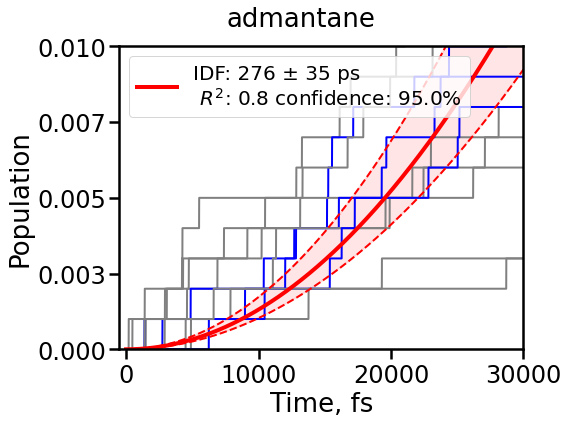

In [8]:
methods = ["IDF"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'IDF': gau_func } 
figuretitle = "admantane"
figurename = "IDF-gau.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level = 0.95, r2_min = 0.8)

icond: 1, r_squared: 0.5936793352422154, tau: [6491965.11700276]
icond: 101, r_squared: 0.8470089169595346, tau: [3682692.03306157]
plotting this batch, the fitted tau is [3682692.03306157]
icond: 201, r_squared: 0.9422540632269538, tau: [2163345.68492387]
plotting this batch, the fitted tau is [2163345.68492387]
icond: 301, r_squared: 0.9178334022661322, tau: [2692020.01822524]
plotting this batch, the fitted tau is [2692020.01822524]
icond: 401, r_squared: 0.8940279709233981, tau: [3532546.49345551]
plotting this batch, the fitted tau is [3532546.49345551]
icond: 501, r_squared: 0.9576400448158127, tau: [3112218.65864642]
plotting this batch, the fitted tau is [3112218.65864642]
icond: 601, r_squared: 0.8797976390301745, tau: [4142193.47568388]
plotting this batch, the fitted tau is [4142193.47568388]
icond: 701, r_squared: 0.8821602420985141, tau: [3831628.91512021]
plotting this batch, the fitted tau is [3831628.91512021]
icond: 801, r_squared: 0.11807631588601986, tau: [8780343.57

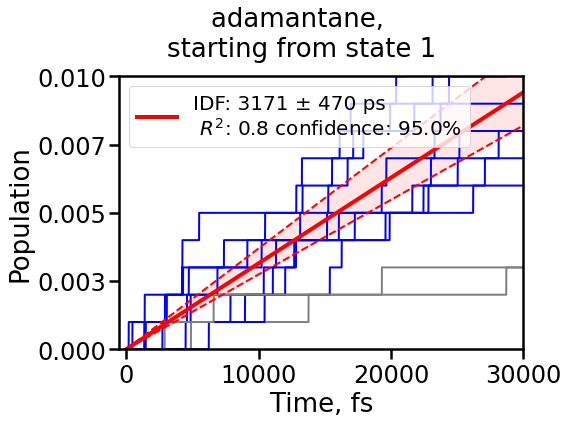

In [9]:
methods = ["IDF"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'IDF': exp_func } 
figuretitle = "adamantane, \nstarting from state 1"
figurename = "IDF-exp.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level = 0.95, r2_min = 0.8)

In [2]:
import warnings
from libra_py import trpes
%matplotlib inline
warnings.filterwarnings("ignore")  # Turn off warnings

<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWar

In [3]:
x = {"istep":3501,"fstep":5499, "dt":1.0, "namd_nsteps":2000*10, "units":"eV",
     "eprefix":"/vscratch/grp-alexeyak/qingxin/devel3/0_align/step2_B3LYP/all_logfiles/step_", "esuffix":".log",
     "input_file_type":1, "logfile_read_params": {"number_of_states":30},
     "iconds":[1, 101,201,301, 401, 501,601,701,801,901], "dprefix":"/vscratch/grp-alexeyak/qingxin/devel3/0_align/step4/S1_IDF/IDF_icond_",
     "dsuffix":"/mem_data.hdf",
     "de":0.1, "emin":0.0, "emax":10, "sigma_e":0.6
    }
time_bins, energy_grid, H_total = trpes.compute_trpes(x)

{'istep': 3501, 'fstep': 5499, 'dt': 1.0, 'namd_nsteps': 20000, 'units': 'eV', 'eprefix': '/vscratch/grp-alexeyak/qingxin/devel3/0_align/step2_B3LYP/all_logfiles/step_', 'esuffix': '.log', 'input_file_type': 1, 'logfile_read_params': {'number_of_states': 30}, 'iconds': [1, 101, 201, 301, 401, 501, 601, 701, 801, 901], 'dprefix': '/vscratch/grp-alexeyak/qingxin/devel3/0_align/step4/S1_IDF/IDF_icond_', 'dsuffix': '/mem_data.hdf', 'de': 0.1, 'emin': 0.0, 'emax': 10, 'sigma_e': 0.6}
Trajectory data contains 19980, while we only want 20000
The TRPES plot will be of the time legnth of 20000 points
The multiplication factor is 9
The shape of the effective E array is (19980, 31)
Initial iconds = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901]
Renormalizing iconds for istep = 3501, fstep = 5499 and nsteps = 19980...
The effective iconds are = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901] (dropping off meaningless iconds)
Reading the file /vscratch/grp-alexeyak/qingxin/devel3/0_align/step4/S

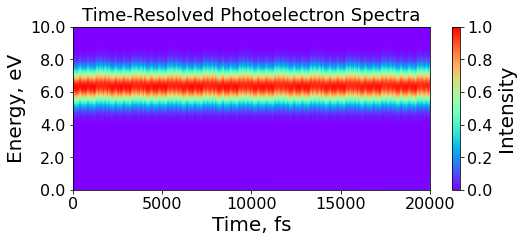

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 绘图
trpes.plot_trpes(time_bins, energy_grid, H_total, { })

# 添加标题
plt.title("Time-Resolved Photoelectron Spectra", fontsize=18)

# 调整 x 轴范围到 0–2000，并设置刻度
plt.xlim(0, 20000)
plt.xticks(np.arange(0, 20001, 5000))  # 刻度从 0 到 2000，步长 500

# 保存为高清图片（白色背景、300 dpi）
plt.savefig(
    "trpes_highresIDF.png",
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
    transparent=False
)

# 显示图像
plt.show()